In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [44]:
df = pd.read_csv ("diabetes_data.csv")
df.head()

,age,gender,bmi,bmi_category,systolic,diastolic,blood_pressure_category,cholesterol,cholesterol_category,glucose,diabetes_probability
0,55,Female,29.59,Overweight,112.0,89.5,Hypertension Stage 1,247,High,139,0.65
1,34,Male,30.68,Obesity,106.0,115.0,Hypertension Stage 2,255,High,101,0.60
2,26,Male,15.96,Underweight,96.0,97.0,Hypertension Stage 2,234,Borderline high,97,0.15
3,63,Male,15.61,Underweight,109.6,115.3,Hypertension Stage 2,261,High,143,0.70
4,37,Male,41.54,Obesity,110.0,103.0,Hypertension Stage 2,226,Borderline high,115,0.50


In [45]:
df.isna().sum()

age                        0
gender                     0
bmi                        0
bmi_category               0
systolic                   0
diastolic                  0
blood_pressure_category    0
cholesterol                0
cholesterol_category       0
glucose                    0
diabetes_probability       0
dtype: int64

In [46]:
X = df.drop(columns=["diabetes_probability"])
y = df["diabetes_probability"]

In [47]:
df = df.drop_duplicates()

In [48]:
df_numeric = df.select_dtypes(include=[np.number])  # Select only numeric columns

# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1  # Compute Interquartile Range

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_cleaned = df_numeric[~((df_numeric < lower_bound) | (df_numeric > upper_bound)).any(axis=1)]

# Display dataset shape after outlier removal
print(f"Dataset shape before outlier removal: {df_numeric.shape}")
print(f"Dataset shape after outlier removal: {df_cleaned.shape}")

Dataset shape before outlier removal: (10000, 7)
Dataset shape after outlier removal: (9938, 7)


In [49]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols.tolist())

# Convert categorical columns using Label Encoding
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['diabetes_probability']))

Categorical Columns: ['gender', 'bmi_category', 'blood_pressure_category', 'cholesterol_category']


In [50]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X[categorical_cols])
X_final = np.concatenate([X.drop(columns=categorical_cols).values, X_encoded], axis=1)

In [51]:
pca = PCA(n_components=2)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

In [52]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

In [53]:
# Define target variable
y = (df['diabetes_probability'] >= 0.5).astype(int)  # Convert to binary
X = df.drop(columns=['diabetes_probability'])

In [54]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [55]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [56]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "kNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Neural Network": MLPClassifier(max_iter=500)
}


In [57]:
# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print("Initial Model Performance:")
print(results_df)

Initial Model Performance:
                     Accuracy  Precision    Recall  F1 Score
Logistic Regression    0.9140   0.918944  0.918944  0.918944
Decision Tree          0.9930   0.990628  0.996230  0.993421
Random Forest          0.9965   0.994371  0.999057  0.996709
SVM                    0.9535   0.945672  0.967955  0.956684
kNN                    0.9585   0.942935  0.981150  0.961663
Gradient Boosting      0.9985   1.000000  0.997172  0.998584
Neural Network         0.9760   0.971163  0.983977  0.977528


In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

param_grid = {
    "Logistic Regression": {
        "C": [0.1, 1],  # Reduced range
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"]
    },
    "Decision Tree": {
        "max_depth": [None, 5],
        "min_samples_split": [2, 5]
    },
    "Random Forest": {
        "n_estimators": [100],
        "max_depth": [None, 10]
    },
    "SVM": {
        "C": [1],
        "kernel": ["linear"]
    },
    "kNN": {
        "n_neighbors": [3, 5],
        "weights": ["uniform"]
    },
    "Gradient Boosting": {
        "n_estimators": [100],
        "learning_rate": [0.1]
    },
    "Neural Network": {
        "hidden_layer_sizes": [(50,)],
        "activation": ["relu"],
        "solver": ["adam"]
    }
}

tuned_results = {}
for name, params in param_grid.items():
    grid_search = GridSearchCV(models[name], params, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)  # Using parallelism and fewer folds
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    tuned_results[name] = {
        "Best Params": grid_search.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\USER\Downloads\anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [59]:
# Print the tuned results DataFrame
tuned_results_df = pd.DataFrame(tuned_results).T  # Transpose to make it easier to read
print("Tuned Model Performance:")
print(tuned_results_df)


Tuned Model Performance:
                                                           Best Params  \
Logistic Regression  {'C': 0.1, 'penalty': 'l1', 'solver': 'libline...   
Decision Tree              {'max_depth': None, 'min_samples_split': 2}   
Random Forest                   {'max_depth': 10, 'n_estimators': 100}   
SVM                                       {'C': 1, 'kernel': 'linear'}   
kNN                           {'n_neighbors': 3, 'weights': 'uniform'}   
Gradient Boosting          {'learning_rate': 0.1, 'n_estimators': 100}   
Neural Network       {'activation': 'relu', 'hidden_layer_sizes': (...   

                    Accuracy Precision    Recall  F1 Score  
Logistic Regression   0.9125  0.917925  0.917059  0.917492  
Decision Tree         0.9945  0.991573  0.998115  0.994833  
Random Forest         0.9965  0.995301  0.998115  0.996706  
SVM                   0.9115  0.915414  0.918002  0.916706  
kNN                   0.9565  0.941924  0.978322  0.959778  
Gradient Boostin

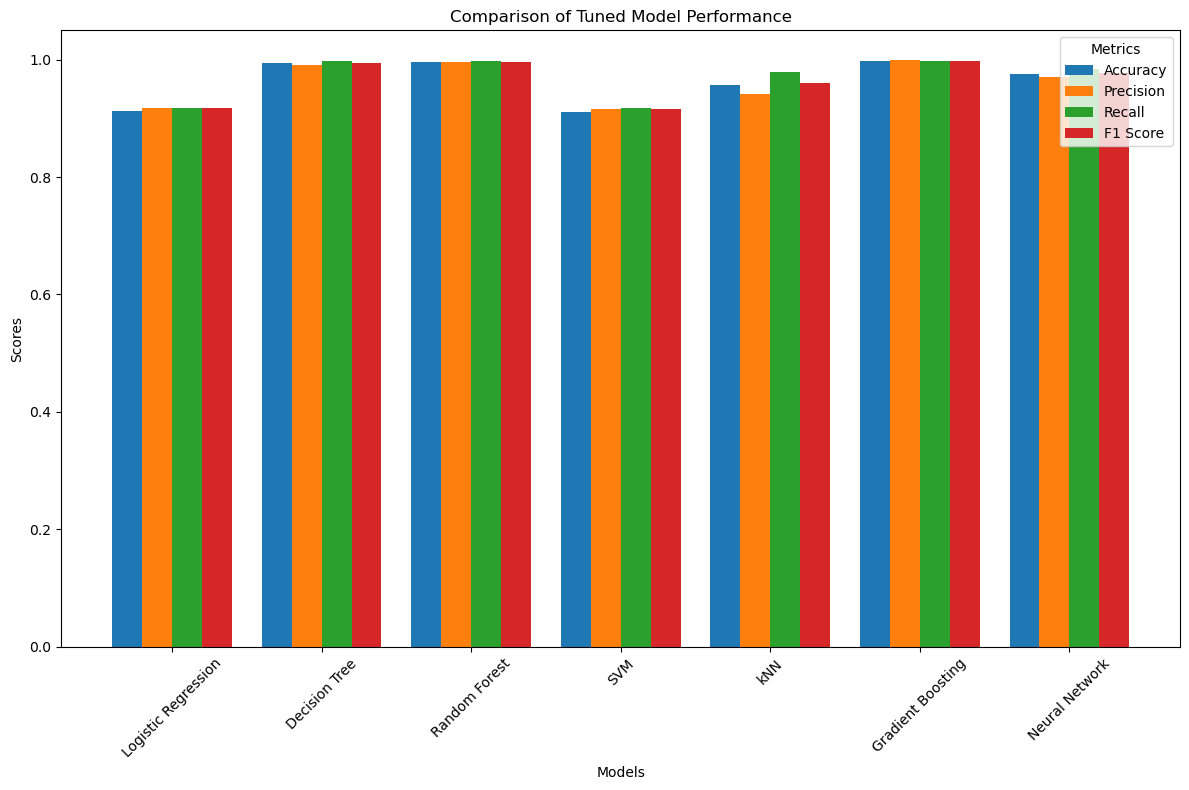

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Extracting performance metrics for the tuned models
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
models = list(tuned_results.keys())

# Prepare the data for the plot (for each model, extract the metrics)
tuned_metrics = np.array([[tuned_results[model][metric] for metric in metrics] for model in models])

# Set up the positions for the bars
bar_width = 0.2
index = np.arange(len(models))

# Plotting the comparison
fig, ax = plt.subplots(figsize=(12, 8))

# Plot bars for each metric
for i, metric in enumerate(metrics):
    ax.bar(index + i * bar_width, tuned_metrics[:, i], bar_width, label=metric)

# Add labels and title
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Tuned Model Performance')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(models, rotation=45)
ax.legend(title='Metrics')

# Show the plot
plt.tight_layout()
plt.show()
